# Flickr8k Image Captioning on Google Colab
Select Runtime > Change runtime type > T4 GPU before running the cells.

In [ ]:
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('Enable a GPU runtime before continuing.')

In [ ]:
%%bash
set -e
cd /content
mkdir -p /content/Idar /content/dataset_extract /content/text_extract
wget -c --show-progress -O Flickr8k_Dataset.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
wget -c --show-progress -O Flickr8k_text.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
unzip -q -o Flickr8k_Dataset.zip -d /content/dataset_extract
unzip -q -o Flickr8k_text.zip -d /content/text_extract
echo 'Archives downloaded and extracted.'

In [ ]:
from pathlib import Path
import shutil

dataset_candidates = list(Path('/content/dataset_extract').glob('*Dataset'))
if not dataset_candidates:
    raise FileNotFoundError('Could not find the extracted Flickr8k image folder.')

target = Path('/content/Idar/Flicker8k_Dataset')
if target.exists():
    shutil.rmtree(target)
shutil.move(str(dataset_candidates[0]), str(target))

image_count = len(list(target.glob('*.jpg')))
print('Image folder:', target)
print('Images:', image_count)

In [ ]:
import csv
from pathlib import Path

token_files = list(Path('/content/text_extract').rglob('Flickr8k.token.txt'))
if not token_files:
    raise FileNotFoundError('Flickr8k.token.txt was not found.')

caption_dir = Path('/content/Idar/flickr8k')
caption_dir.mkdir(parents=True, exist_ok=True)
caption_file = caption_dir / 'captions.txt'

with token_files[0].open(encoding='utf-8') as source, caption_file.open('w', newline='', encoding='utf-8') as target_file:
    writer = csv.writer(target_file)
    writer.writerow(['image', 'caption'])
    for line in source:
        image_id, caption = line.rstrip('\n').split('\t', 1)
        image_name = image_id.rsplit('#', 1)[0]
        writer.writerow([image_name, caption])

print('Caption file:', caption_file)
print('Caption rows:', sum(1 for _ in caption_file.open(encoding='utf-8')) - 1)

In [ ]:
from google.colab import files

%cd /content/Idar
uploaded = files.upload()
print('Uploaded:', ', '.join(uploaded.keys()))

In [ ]:
%cd /content/Idar
!pip install -q tensorboard
!find Flicker8k_Dataset -name '1000268201_693b08cb0e.jpg'
!test -f flickr8k/captions.txt && echo 'Dataset paths are ready.'

In [ ]:
from pathlib import Path

train_file = Path('/content/Idar/train.py')
text = train_file.read_text()
text = text.replace('num_epochs =100', 'num_epochs = 1')
text = text.replace('num_epochs = 10', 'num_epochs = 1')
train_file.write_text(text)
print('Configured one epoch for the first test run.')

In [ ]:
%cd /content/Idar
!python train.py

In [11]:
%pip install -q transformers

from transformers import AutoProcessor, AutoModelForCausalLM

model_name = "microsoft/git-large-textcaps"
print("Downloading detailed-caption model files...")
AutoProcessor.from_pretrained(model_name)
AutoModelForCausalLM.from_pretrained(model_name)
print("Detailed-caption model files downloaded and cached.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Loading weights: 100%|██████████| 497/497 [00:00<00:00, 47070.61it/s]


Detailed-caption model files downloaded and cached.


In [12]:
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

try:
    from google.colab import files
    running_in_colab = True
except ModuleNotFoundError:
    running_in_colab = False

model_name = "microsoft/git-large-textcaps"
device = torch.device(
    "cuda" if running_in_colab and torch.cuda.is_available() else "cpu"
)

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

print(f"Detailed-caption model initialized on {device}.")

Loading weights: 100%|██████████| 497/497 [00:00<00:00, 29007.14it/s]

Detailed-caption model initialized on cpu.


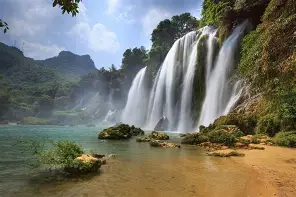

Detailed image description:
a waterfall in the middle of a forest with a mountain in the background.


In [15]:
from pathlib import Path
from IPython.display import display
from PIL import Image

try:
    from google.colab import files
    running_in_colab = True
except ModuleNotFoundError:
    running_in_colab = False

if running_in_colab:
    uploaded = files.upload()
    image_path = Path(next(iter(uploaded)))
else:
    import shutil
    import subprocess

    zenity = shutil.which("zenity")
    if zenity is None:
        raise RuntimeError(
            "Fedora native picker requires zenity. Install it with: sudo dnf install zenity"
        )

    result = subprocess.run(
        [
            zenity,
            "--file-selection",
            "--title=Select an image",
            "--file-filter=Images | *.jpg *.jpeg *.png *.webp",
        ],
        check=False,
        capture_output=True,
        text=True,
    )
    image_path = Path(result.stdout.strip()) if result.returncode == 0 else Path()

if not image_path.is_file():
    raise FileNotFoundError("No valid image was selected.")

image = Image.open(image_path).convert("RGB")
display(image)
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(
        pixel_values=inputs.pixel_values,
        max_new_tokens=100,
        num_beams=5,
        repetition_penalty=1.1,
        no_repeat_ngram_size=3,
    )

description = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
print("Detailed image description:")
print(description)